# 0. Install and Import Dependencies

In [112]:
!pip list

Package                      Version
---------------------------- -----------
absl-py                      2.3.0
astunparse                   1.6.3
beautifulsoup4               4.13.4
cachetools                   5.5.2
certifi                      2025.4.26
charset-normalizer           3.4.2
colorama                     0.4.6
contourpy                    1.1.1
cycler                       0.12.1
filelock                     3.16.1
flatbuffers                  25.2.10
fonttools                    4.57.0
gast                         0.4.0
gdown                        5.2.0
google-auth                  2.40.3
google-auth-oauthlib         1.0.0
google-pasta                 0.2.0
grpcio                       1.70.0
h5py                         3.11.0
idna                         3.10
imageio                      2.35.1
importlib_metadata           8.5.0
importlib_resources          6.4.5
joblib                       1.4.2
keras                        2.13.1
kiwisolver                   1.4.

In [113]:
!pip install opencv-python matplotlib imageio gdown tensorflow

In [1]:
import numpy as np
import cv2
import matplotlib
import imageio
import gdown
import tensorflow as tf

print("✔ NumPy:", np.__version__)
print("✔ OpenCV:", cv2.__version__)
print("✔ Matplotlib:", matplotlib.__version__)
print("✔ ImageIO:", imageio.__version__)
print("✔ gdown:", gdown.__version__)
print("✔ TensorFlow:", tf.__version__)
print("✔ GPU Available:", tf.config.list_physical_devices('GPU'))


✔ NumPy: 1.23.5
✔ OpenCV: 4.6.0
✔ Matplotlib: 3.6.2
✔ ImageIO: 2.23.0
✔ gdown: 4.6.0
✔ TensorFlow: 2.10.1
✔ GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import os
import cv2
import tensorflow as tf
import numpy as np
from typing import List
from matplotlib import pyplot as plt
import imageio

In [3]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [4]:
physical_devices = tf.config.list_physical_devices('GPU')
try:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
except:
    pass

# 1. Build Data Loading Functions

In [4]:
import gdown

In [69]:
url = 'https://drive.google.com/uc?id=1kjUJpZ_F_1kjuQDKF4zdKxEuo4LVv9rl'
output = 'models - checkpoint 96.zip'
gdown.download(url, output, quiet=False)
gdown.extractall('models - checkpoint 96.zip')

Downloading...
From: https://drive.google.com/uc?id=1kjUJpZ_F_1kjuQDKF4zdKxEuo4LVv9rl
To: C:\Users\nithi\OneDrive\Desktop\PR\LipNet-main\models - checkpoint 96.zip
100%|█████████████████████████████████████████████████████████████████████████████| 94.5M/94.5M [00:16<00:00, 5.87MB/s]


['models - checkpoint 96/',
 'models - checkpoint 96/models - checkpoint 96/',
 'models - checkpoint 96/models - checkpoint 96/checkpoint',
 'models - checkpoint 96/models - checkpoint 96/checkpoint.data-00000-of-00001',
 'models - checkpoint 96/models - checkpoint 96/checkpoint.index',
 'models - checkpoint 96/models - checkpoint 96/__MACOSX/',
 'models - checkpoint 96/models - checkpoint 96/__MACOSX/._checkpoint',
 'models - checkpoint 96/models - checkpoint 96/__MACOSX/._checkpoint.data-00000-of-00001',
 'models - checkpoint 96/models - checkpoint 96/__MACOSX/._checkpoint.index']

In [70]:
url = 'https://drive.google.com/uc?id=1g-z2fXnUYeBog9l6HRKe5P-3b0ev5io2'
output = 'models - checkpoint 50.zip'
gdown.download(url, output, quiet=False)
gdown.extractall('models - checkpoint 50.zip')

Downloading...
From: https://drive.google.com/uc?id=1g-z2fXnUYeBog9l6HRKe5P-3b0ev5io2
To: C:\Users\nithi\OneDrive\Desktop\PR\LipNet-main\models - checkpoint 50.zip
100%|█████████████████████████████████████████████████████████████████████████████| 94.5M/94.5M [00:11<00:00, 7.93MB/s]


['models - checkpoint 50/',
 'models - checkpoint 50/models - checkpoint 50/',
 'models - checkpoint 50/models - checkpoint 50/models/',
 'models - checkpoint 50/models - checkpoint 50/models/checkpoint',
 'models - checkpoint 50/models - checkpoint 50/models/checkpoint.data-00000-of-00001',
 'models - checkpoint 50/models - checkpoint 50/models/checkpoint.index',
 'models - checkpoint 50/models - checkpoint 50/__MACOSX/',
 'models - checkpoint 50/models - checkpoint 50/__MACOSX/models/',
 'models - checkpoint 50/models - checkpoint 50/__MACOSX/models/._checkpoint',
 'models - checkpoint 50/models - checkpoint 50/__MACOSX/models/._checkpoint.data-00000-of-00001',
 'models - checkpoint 50/models - checkpoint 50/__MACOSX/models/._checkpoint.index']

In [71]:
url = 'https://drive.google.com/uc?id=1CsnDD7esgb-wtOmF2ABpFNf3V1nJjc0-'
output = 'data.zip'
gdown.download(url, output, quiet=False)
gdown.extractall('data.zip')

Downloading...
From: https://drive.google.com/uc?id=1CsnDD7esgb-wtOmF2ABpFNf3V1nJjc0-
To: C:\Users\nithi\OneDrive\Desktop\PR\LipNet-main\data.zip
100%|█████████████████████████████████████████████████████████████████████████████| 15.4M/15.4M [00:01<00:00, 8.60MB/s]


['data/',
 'data/alignments/',
 'data/alignments/s1/',
 'data/alignments/s1/bbaf2n.align',
 'data/alignments/s1/bbaf3s.align',
 'data/alignments/s1/bbaf4p.align',
 'data/alignments/s1/bbaf5a.align',
 'data/alignments/s1/bbal6n.align',
 'data/alignments/s1/bbal7s.align',
 'data/alignments/s1/bbal8p.align',
 'data/alignments/s1/bbal9a.align',
 'data/alignments/s1/bbas1s.align',
 'data/alignments/s1/bbas2p.align',
 'data/alignments/s1/bbas3a.align',
 'data/alignments/s1/bbaszn.align',
 'data/alignments/s1/bbaz4n.align',
 'data/alignments/s1/bbaz5s.align',
 'data/alignments/s1/bbaz6p.align',
 'data/alignments/s1/bbaz7a.align',
 'data/alignments/s1/bbbf6n.align',
 'data/alignments/s1/bbbf7s.align',
 'data/alignments/s1/bbbf8p.align',
 'data/alignments/s1/bbbf9a.align',
 'data/alignments/s1/bbbm1s.align',
 'data/alignments/s1/bbbm2p.align',
 'data/alignments/s1/bbbm3a.align',
 'data/alignments/s1/bbbmzn.align',
 'data/alignments/s1/bbbs4n.align',
 'data/alignments/s1/bbbs5s.align',
 'data/al

In [121]:
def load_video(path:str) -> List[float]:

    cap = cv2.VideoCapture(path)
    frames = []
    for _ in range(int(cap.get(cv2.CAP_PROP_FRAME_COUNT))):
        ret, frame = cap.read()
        frame = tf.image.rgb_to_grayscale(frame)
        frames.append(frame[190:236,80:220,:])
    cap.release()

    mean = tf.math.reduce_mean(frames)
    std = tf.math.reduce_std(tf.cast(frames, tf.float32))
    return tf.cast((frames - mean), tf.float32) / std

In [122]:
vocab = [x for x in "abcdefghijklmnopqrstuvwxyz'?!123456789 "]

In [123]:
char_to_num = tf.keras.layers.StringLookup(vocabulary=vocab, oov_token="")
num_to_char = tf.keras.layers.StringLookup(
    vocabulary=char_to_num.get_vocabulary(), oov_token="", invert=True
)

print(
    f"The vocabulary is: {char_to_num.get_vocabulary()} "
    f"(size ={char_to_num.vocabulary_size()})"
)

The vocabulary is: ['', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', "'", '?', '!', '1', '2', '3', '4', '5', '6', '7', '8', '9', ' '] (size =40)


In [124]:
char_to_num.get_vocabulary()

['',
 'a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z',
 "'",
 '?',
 '!',
 '1',
 '2',
 '3',
 '4',
 '5',
 '6',
 '7',
 '8',
 '9',
 ' ']

In [125]:
char_to_num(['n','i','c','k'])

<tf.Tensor: shape=(4,), dtype=int64, numpy=array([14,  9,  3, 11], dtype=int64)>

In [126]:
num_to_char([14,  9,  3, 11])

<tf.Tensor: shape=(4,), dtype=string, numpy=array([b'n', b'i', b'c', b'k'], dtype=object)>

In [127]:
def load_alignments(path:str) -> List[str]:
    with open(path, 'r') as f:
        lines = f.readlines()
    tokens = []
    for line in lines:
        line = line.split()
        if line[2] != 'sil':
            tokens = [*tokens,' ',line[2]]
    return char_to_num(tf.reshape(tf.strings.unicode_split(tokens, input_encoding='UTF-8'), (-1)))[1:]

In [128]:
# def load_data(path: str):
#     path = bytes.decode(path.numpy())
#     #file_name = path.split('/')[-1].split('.')[0]
#     # File name splitting for windows
#     file_name = path.split('\\')[-1].split('.')[0]
#     video_path = os.path.join('data','s1',f'{file_name}.mpg')
#     alignment_path = os.path.join('data','alignments','s1',f'{file_name}.align')
#     frames = load_video(video_path)
#     alignments = load_alignments(alignment_path)

#     return frames, alignments

def load_data(path: str):
    path = bytes.decode(path.numpy())
    path = path.replace('\\', '/')
    path = os.path.abspath(path)

    file_name = os.path.splitext(os.path.basename(path))[0]
    speaker = os.path.basename(os.path.dirname(path))  # 's1'

    video_path = path
    alignment_path = os.path.join(os.path.dirname(os.path.dirname(path)), 'alignments', speaker, f'{file_name}.align')
    alignment_path = os.path.abspath(alignment_path)

    # print(f"Video path: {video_path}")
    # print(f"Alignment path: {alignment_path}")

    frames = load_video(video_path)
    alignments = load_alignments(alignment_path)

    return frames, alignments

In [129]:
test_path = '.\\data\\s1\\bbaf2n.mpg'

In [130]:
tf.convert_to_tensor(test_path).numpy().decode('utf-8').split('\\')[-1].split('.')[0]

'bbaf2n'

In [131]:
frames, alignments = load_data(tf.convert_to_tensor(test_path))

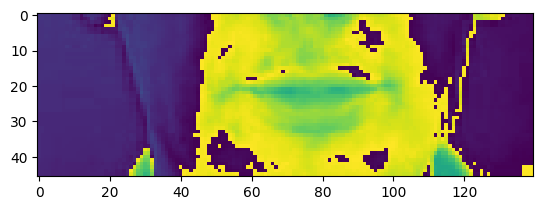

In [132]:
plt.imshow(frames[40])

In [133]:
alignments

<tf.Tensor: shape=(21,), dtype=int64, numpy=
array([ 2,  9, 14, 39,  2, 12, 21,  5, 39,  1, 20, 39,  6, 39, 20, 23, 15,
       39, 14, 15, 23], dtype=int64)>

In [134]:
tf.strings.reduce_join([bytes.decode(x) for x in num_to_char(alignments.numpy()).numpy()])

<tf.Tensor: shape=(), dtype=string, numpy=b'bin blue at f two now'>

In [135]:
def mappable_function(path:str) ->List[str]:
    result = tf.py_function(load_data, [path], (tf.float32, tf.int64))
    return result

# 2. Create Data Pipeline

In [136]:
from matplotlib import pyplot as plt

In [137]:
# import tensorflow as tf

# # List and shuffle file paths
# file_list = tf.data.Dataset.list_files('./data/s1/*.mpg', shuffle=False)
# file_list = file_list.shuffle(36, reshuffle_each_iteration=False)

# # Split before mapping/batching
# train_files = file_list.take(28)
# test_files = file_list.skip(28)

# # Map, batch, and prefetch train
# train = train_files.map(mappable_function)
# train = train.padded_batch(2, padded_shapes=([75, None, None, None], [40]))
# train = train.prefetch(tf.data.AUTOTUNE)

# # Map, batch, and prefetch test
# test = test_files.map(mappable_function)
# test = test.padded_batch(2, padded_shapes=([75, None, None, None], [40]))
# test = test.prefetch(tf.data.AUTOTUNE)

# # Print dataset sizes (batches)
# print("Train size:", train.cardinality().numpy())  # Should be 14 (28 samples / 2 per batch)
# print("Test size:", test.cardinality().numpy())    # Should be 4 (8 samples / 2 per batch)


In [138]:
# print("Train size:", train.cardinality().numpy())  # should print 28
# print("Test size:", test.cardinality().numpy())    # should print 8
# #

In [139]:
data = tf.data.Dataset.list_files('./data/s1/*.mpg')
data = data.shuffle(500, reshuffle_each_iteration=False)
data = data.map(mappable_function)
data = data.padded_batch(2, padded_shapes=([75,None,None,None],[40]))
data = data.prefetch(tf.data.AUTOTUNE)
# Added for split
train = data.take(36)
test = data.skip(36)


In [140]:
# List all 36 files
files = tf.data.Dataset.list_files('./data/s1/*.mpg', shuffle=True)

# Split into 28 files for training, 8 for testing (36 total)
train_files = files.take(28)
test_files = files.skip(28)

# Define mappable function
train = train_files.map(mappable_function)
train = train.padded_batch(1, padded_shapes=([75, None, None, None], [40]))
train = train.prefetch(tf.data.AUTOTUNE)

test = test_files.map(mappable_function)
test = test.padded_batch(1, padded_shapes=([75, None, None, None], [40]))
test = test.prefetch(tf.data.AUTOTUNE)

# Check how many batches each has
print("Train batches:", train.cardinality().numpy())  # Should be 14
print("Test batches:", test.cardinality().numpy())    # Should be 4


Train batches: 28
Test batches: 8


In [141]:
len(test)

8

In [142]:
import os
print(os.getcwd())

C:\Users\nithi\OneDrive\Desktop\PR\LipNet-main


In [143]:
print(test.cardinality().numpy())


8


In [144]:
frames, alignments = data.as_numpy_iterator().next()

In [145]:
len(frames)

2

In [146]:
sample = data.as_numpy_iterator()

In [147]:
val = sample.next();val[0]

array([[[[[1.3981657 ],
          [1.3981657 ],
          [1.4370036 ],
          ...,
          [0.2330276 ],
          [9.748322  ],
          [9.321104  ]],

         [[1.3981657 ],
          [1.3981657 ],
          [1.4370036 ],
          ...,
          [9.825997  ],
          [9.437618  ],
          [9.515294  ]],

         [[1.3981657 ],
          [1.3981657 ],
          [1.3981657 ],
          ...,
          [9.670646  ],
          [9.78716   ],
          [9.631807  ]],

         ...,

         [[0.9321104 ],
          [0.9321104 ],
          [0.9321104 ],
          ...,
          [9.825997  ],
          [9.78716   ],
          [9.78716   ]],

         [[0.9321104 ],
          [0.9321104 ],
          [0.9321104 ],
          ...,
          [9.903673  ],
          [9.864836  ],
          [9.864836  ]],

         [[0.9321104 ],
          [0.9321104 ],
          [0.9321104 ],
          ...,
          [9.903673  ],
          [9.864836  ],
          [9.825997  ]]],


        [[[1.3981

In [148]:
import numpy as np
import imageio

frames = val[0][1]  # Assuming this is a list or array of frames

# Convert frames to proper shape and dtype
processed_frames = []
for frame in frames:
    frame = np.squeeze(frame)  # Remove singleton dimensions
    frame = np.clip(frame, 0, 1)  # Ensure values are in [0,1] if float
    frame = (frame * 255).astype(np.uint8)  # Convert to uint8
    if frame.ndim == 2:  # If grayscale, make it RGB
        frame = np.stack([frame]*3, axis=-1)
    processed_frames.append(frame)

# Save the GIF
imageio.mimsave('./animation.gif', processed_frames, fps=10)


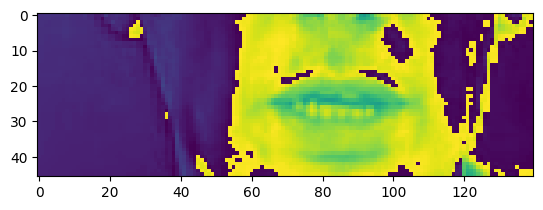

In [149]:
# 0:videos, 0: 1st video out of the batch,  0: return the first frame in the video
plt.imshow(val[0][0][35])

In [150]:
tf.strings.reduce_join([num_to_char(word) for word in val[1][0]])

<tf.Tensor: shape=(), dtype=string, numpy=b'bin blue by f nine again'>

# 3. Design the Deep Neural Network

In [151]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv3D, LSTM, Dense, Dropout, Bidirectional, MaxPool3D, Activation, Reshape, SpatialDropout3D, BatchNormalization, TimeDistributed, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler

In [152]:
data.as_numpy_iterator().next()[0][0].shape

(75, 46, 140, 1)

In [153]:
model = Sequential()
model.add(Conv3D(128, 3, input_shape=(75,46,140,1), padding='same'))
model.add(Activation('relu'))
model.add(MaxPool3D((1,2,2)))

model.add(Conv3D(256, 3, padding='same'))
model.add(Activation('relu'))
model.add(MaxPool3D((1,2,2)))

model.add(Conv3D(75, 3, padding='same'))
model.add(Activation('relu'))
model.add(MaxPool3D((1,2,2)))

model.add(TimeDistributed(Reshape((-1,)))  # assumes the inner dimensions are fixed
)  # assumes the inner dimensions are fixed


model.add(Bidirectional(LSTM(128, kernel_initializer='Orthogonal', return_sequences=True)))
model.add(Dropout(.5))

model.add(Bidirectional(LSTM(128, kernel_initializer='Orthogonal', return_sequences=True)))
model.add(Dropout(.5))

model.add(Dense(char_to_num.vocabulary_size()+1, kernel_initializer='he_normal', activation='softmax'))

In [154]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv3d_3 (Conv3D)           (None, 75, 46, 140, 128)  3584      
                                                                 
 activation_3 (Activation)   (None, 75, 46, 140, 128)  0         
                                                                 
 max_pooling3d_3 (MaxPooling  (None, 75, 23, 70, 128)  0         
 3D)                                                             
                                                                 
 conv3d_4 (Conv3D)           (None, 75, 23, 70, 256)   884992    
                                                                 
 activation_4 (Activation)   (None, 75, 23, 70, 256)   0         
                                                                 
 max_pooling3d_4 (MaxPooling  (None, 75, 11, 35, 256)  0         
 3D)                                                  

In [155]:
5*17*75

6375

In [156]:
yhat = model.predict(val[0])

1/1 [==============================] - 1s 1s/step


In [157]:
tf.strings.reduce_join([num_to_char(x) for x in tf.argmax(yhat[0],axis=1)])

<tf.Tensor: shape=(), dtype=string, numpy=b'jjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjj'>

In [158]:
tf.strings.reduce_join([num_to_char(tf.argmax(x)) for x in yhat[0]])

<tf.Tensor: shape=(), dtype=string, numpy=b'jjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjjj'>

In [159]:
model.input_shape

(None, 75, 46, 140, 1)

In [160]:
model.output_shape

(None, 75, 41)

# 4. Setup Training Options and Train

In [161]:
import numpy as np

def scheduler(epoch, lr):
    if epoch < 30:
        return lr
    else:
        return float(lr * np.exp(-0.1))


In [162]:
def CTCLoss(y_true, y_pred):
    batch_len = tf.cast(tf.shape(y_true)[0], dtype="int64")
    input_length = tf.cast(tf.shape(y_pred)[1], dtype="int64")
    label_length = tf.cast(tf.shape(y_true)[1], dtype="int64")

    input_length = input_length * tf.ones(shape=(batch_len, 1), dtype="int64")
    label_length = label_length * tf.ones(shape=(batch_len, 1), dtype="int64")

    loss = tf.keras.backend.ctc_batch_cost(y_true, y_pred, input_length, label_length)
    return loss

In [163]:
class ProduceExample(tf.keras.callbacks.Callback):
    def __init__(self, dataset) -> None:
        self.dataset = dataset.as_numpy_iterator()

    def on_epoch_end(self, epoch, logs=None) -> None:
        data = self.dataset.next()
        yhat = self.model.predict(data[0])
        decoded = tf.keras.backend.ctc_decode(yhat, [75,75], greedy=False)[0][0].numpy()
        for x in range(len(yhat)):
            print('Original:', tf.strings.reduce_join(num_to_char(data[1][x])).numpy().decode('utf-8'))
            print('Prediction:', tf.strings.reduce_join(num_to_char(decoded[x])).numpy().decode('utf-8'))
            print('~'*100)

In [164]:
model.compile(optimizer=Adam(learning_rate=0.0001), loss=CTCLoss)

In [165]:
from keras.callbacks import ModelCheckpoint
import os

checkpoint_callback = ModelCheckpoint(
    os.path.join('models', 'checkpoint.weights.h5'),  # must end in `.weights.h5`
    monitor='loss',
    save_weights_only=True
)


In [166]:
schedule_callback = LearningRateScheduler(scheduler)

In [167]:
example_callback = ProduceExample(test)

In [168]:
import tensorflow as tf
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))


Num GPUs Available: 1


In [53]:
import tensorflow as tf
print("GPUs:", tf.config.list_physical_devices('GPU'))


GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [169]:
# class ProduceExample(tf.keras.callbacks.Callback):
#     def __init__(self, dataset):
#         super().__init__()
#         self.dataset = dataset

#     def on_epoch_end(self, epoch, logs=None):
#         try:
#             data_iter = iter(self.dataset)
#             data = next(data_iter)
#         except StopIteration:
#             print("⚠️ Dataset is empty or already exhausted.")
#             return

#         x_batch = data[0]
#         yhat = self.model.predict(x_batch)

#         print("yhat shape:", yhat.shape)  # (2, 75, 41) ✅

#         # (Optional) Apply softmax if your model does not already
#         yhat = tf.nn.softmax(yhat)

#         # Correct sequence lengths
#         sequence_lengths = tf.fill([tf.shape(yhat)[0]], tf.shape(yhat)[1])

#         # Decode using CTC
#         decoded, _ = tf.keras.backend.ctc_decode(yhat, sequence_lengths, greedy=False)
#         decoded = decoded[0].numpy()

#         print(f"\n📢 Prediction at epoch {epoch}: {decoded}")



# class ProduceExample(tf.keras.callbacks.Callback):
#     def __init__(self, dataset, id_to_char, blank_index=0):
#         super().__init__()
#         self.dataset = dataset.take(1)  # take one batch only
#         self.id_to_char = id_to_char
#         self.blank_index = blank_index

#     def on_epoch_end(self, epoch, logs=None):
#         try:
#             data_iter = iter(self.dataset)
#             x_batch, y_true = next(data_iter)
#         except StopIteration:
#             print("⚠️ Dataset is empty or exhausted.")
#             return

#         yhat = self.model.predict(x_batch)
#         print("yhat shape:", yhat.shape)  # e.g., (batch_size, time_steps, num_classes)

#         # Apply softmax if not applied inside the model
#         yhat = tf.nn.softmax(yhat)

#         # Prepare sequence lengths (time dimension)
#         sequence_lengths = tf.fill([tf.shape(yhat)[0]], tf.shape(yhat)[1])
#         sequence_lengths = tf.cast(sequence_lengths, tf.int32)

#         # CTC decode (greedy or beam search)
#         decoded_sparse, _ = tf.keras.backend.ctc_decode(yhat, sequence_lengths, greedy=True)

#         # Convert sparse tensor to dense with padding -1
#         decoded_dense = tf.sparse.to_dense(decoded_sparse[0], default_value=-1).numpy()

#         for seq in decoded_dense:
#             # Filter out padding and blank tokens
#             filtered_seq = [i for i in seq if i != -1 and i != self.blank_index]

#             # Map IDs to chars (fallback to '?')
#             decoded_text = ''.join(self.id_to_char.get(i, '?') for i in filtered_seq)

#             print(f"Epoch {epoch + 1} decoded example: {decoded_text}")


class ProduceExample(tf.keras.callbacks.Callback):
    def __init__(self, dataset, id_to_char=None, blank_index=0):
        super().__init__()
        self.dataset = dataset.take(1)  # Just one batch for example
        self.id_to_char = id_to_char
        self.blank_index = blank_index

    def on_epoch_end(self, epoch, logs=None):
        try:
            data_iter = iter(self.dataset)
            x_batch, _ = next(data_iter)
        except StopIteration:
            print("⚠️ Dataset empty or exhausted.")
            return

        # Predict
        yhat = self.model.predict(x_batch)
        print("yhat shape:", yhat.shape)

        # Apply softmax if needed
        yhat = tf.nn.softmax(yhat)

        # Sequence lengths = max time steps in batch
        sequence_lengths = tf.fill([tf.shape(yhat)[0]], tf.shape(yhat)[1])

        # Decode using CTC (beam search)
        decoded, log_prob = tf.keras.backend.ctc_decode(yhat, sequence_lengths, greedy=False)

        decoded_output = decoded[0]

        # Handle sparse or dense decoded output
        if isinstance(decoded_output, tf.SparseTensor):
            decoded_dense = tf.sparse.to_dense(decoded_output, default_value=-1)
        else:
            decoded_dense = decoded_output

        decoded_np = decoded_dense.numpy()

        for seq in decoded_np:
            # Remove padding (-1) and blank index
            clean_seq = [x for x in seq if x != -1 and x != self.blank_index]

            print(f"Epoch {epoch+1} decoded sequence (IDs):", clean_seq)

            if self.id_to_char:
                decoded_text = ''.join([self.id_to_char.get(i, '?') for i in clean_seq])
                print(f"Epoch {epoch+1} decoded text:", decoded_text)




In [170]:
print("yhat shape:", yhat.shape)


yhat shape: (2, 75, 41)


In [171]:
vocab = ['-', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm',
         'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
id_to_char = {i: c for i, c in enumerate(vocab)}
blank_index = 0

example_callback = ProduceExample(test, id_to_char, blank_index)


In [172]:
example_callback = ProduceExample(test, id_to_char, blank_index)


In [173]:
sequence_lengths = tf.fill([tf.shape(yhat)[0]], tf.shape(yhat)[1])
print("yhat shape:", yhat.shape)
print("sequence_lengths:", sequence_lengths)
print("sequence_lengths shape:", sequence_lengths.shape)
print("sequence_lengths dtype:", sequence_lengths.dtype)
print("yhat dtype:", yhat.dtype)


yhat shape: (2, 75, 41)
sequence_lengths: tf.Tensor([75 75], shape=(2,), dtype=int32)
sequence_lengths shape: (2,)
sequence_lengths dtype: <dtype: 'int32'>
yhat dtype: float32


In [174]:
import tensorflow as tf

# Simulated model output
yhat = tf.random.uniform((1, 75, 41), dtype=tf.float32)

# Create sequence lengths tensor
sequence_lengths = tf.fill([tf.shape(yhat)[0]], tf.shape(yhat)[1])
sequence_lengths = tf.cast(sequence_lengths, tf.int32)

# CTC greedy decode expects inputs as [max_time, batch_size, num_classes]
yhat_t = tf.transpose(yhat, [1, 0, 2])  # shape (75, 1, 41)

# Decode using CTC greedy decoder
decoded, log_prob = tf.nn.ctc_greedy_decoder(
    inputs=yhat_t,
    sequence_length=sequence_lengths
)

print("Decoded sparse tensor:", decoded)
print("Log probability:", log_prob)


Decoded sparse tensor: [<tensorflow.python.framework.sparse_tensor.SparseTensor object at 0x000001518CD0B1C0>]
Log probability: tf.Tensor([[-73.24909]], shape=(1, 1), dtype=float32)


In [175]:
decoded_dense = tf.sparse.to_dense(decoded[0], default_value=-1)
print("Decoded dense shape:", decoded_dense.shape)
print("Decoded dense values:", decoded_dense.numpy())


Decoded dense shape: (1, 72)
Decoded dense values: [[38 17 32 36 11 34  4 25 12 11 24 30 21 27 13 28 33 19 23  1 19 34 21  3
   6 27  9 32  1 31 35 29 19  8 17 11  0 10  5  3 29 36 12 20 35 16 25 13
  22 13 20 12 28 19  4 12 14 13 21 10 29 10 22 25 29 25 13 10  9 31 17 13]]


In [176]:
decoded_dense = tf.sparse.to_dense(decoded[0], default_value=-1)

# Convert tensor to numpy for easier processing
decoded_np = decoded_dense.numpy()

for seq in decoded_np:
    # Remove padding (-1) values
    clean_seq = [x for x in seq if x != -1]
    print("Decoded sequence (class IDs):", clean_seq)

    # If you have a mapping from class IDs to chars:
    # decoded_text = ''.join([id_to_char[id] for id in clean_seq])
    # print("Decoded text:", decoded_text)


Decoded sequence (class IDs): [38, 17, 32, 36, 11, 34, 4, 25, 12, 11, 24, 30, 21, 27, 13, 28, 33, 19, 23, 1, 19, 34, 21, 3, 6, 27, 9, 32, 1, 31, 35, 29, 19, 8, 17, 11, 0, 10, 5, 3, 29, 36, 12, 20, 35, 16, 25, 13, 22, 13, 20, 12, 28, 19, 4, 12, 14, 13, 21, 10, 29, 10, 22, 25, 29, 25, 13, 10, 9, 31, 17, 13]


In [177]:
print(type(test))


<class 'tensorflow.python.data.ops.dataset_ops.PrefetchDataset'>


In [178]:
print(test)  # Check structure
print(test.cardinality().numpy())

<PrefetchDataset element_spec=(TensorSpec(shape=(None, 75, None, None, None), dtype=tf.float32, name=None), TensorSpec(shape=(None, 40), dtype=tf.int64, name=None))>
8


In [ ]:
# Define your vocabulary and mapping
vocab = [x for x in "abcdefghijklmnopqrstuvwxyz'?!123456789 "]
id_to_char = {i: c for i, c in enumerate(vocab)}
blank_index = 0  # Usually 0 for CTC blank

example_callback = ProduceExample(test, id_to_char, blank_index)

model.fit(
    train,
    validation_data=test,
    epochs=400,
    callbacks=[checkpoint_callback, schedule_callback, example_callback]
)



# 5. Make a Prediction

In [107]:
url = 'https://drive.google.com/uc?id=1vWscXs4Vt0a_1IH1-ct2TCgXAZT-N3_Y'
output = 'checkpoints.zip'
gdown.download(url, output, quiet=False)
gdown.extractall('checkpoints.zip', 'models')

Downloading...
From: https://drive.google.com/uc?id=1vWscXs4Vt0a_1IH1-ct2TCgXAZT-N3_Y
To: C:\Users\nithi\OneDrive\Desktop\PR\LipNet-main\checkpoints.zip
100%|█████████████████████████████████████████████████████████████████████████████| 94.5M/94.5M [00:16<00:00, 5.62MB/s]


['models\\checkpoint.index',
 'models\\__MACOSX/._checkpoint.index',
 'models\\checkpoint.data-00000-of-00001',
 'models\\__MACOSX/._checkpoint.data-00000-of-00001',
 'models\\checkpoint',
 'models\\__MACOSX/._checkpoint']

In [262]:
model.load_weights('models/checkpoint')

In [263]:
model.save_weights('models/checkpoint.weights.h5')

In [250]:
print(test)  # Check structure
print(test.cardinality().numpy())  # Check number of batches


<PrefetchDataset element_spec=(TensorSpec(shape=(None, 75, None, None, None), dtype=tf.float32, name=None), TensorSpec(shape=(None, 40), dtype=tf.int64, name=None))>
8


In [251]:


test_data = test.as_numpy_iterator()  # re-create it
sample = next(test_data)


In [252]:
sample = test_data.next()

In [253]:
yhat = model.predict(sample[0])

1/1 [==============================] - 0s 450ms/step


In [254]:
print('~'*100, 'REAL TEXT')
[tf.strings.reduce_join([num_to_char(word) for word in sentence]) for sentence in sample[1]]

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ REAL TEXT


[<tf.Tensor: shape=(), dtype=string, numpy=b'bin blue by f six now'>]

In [255]:
decoded = tf.keras.backend.ctc_decode(yhat, input_length=[75], greedy=True)[0][0].numpy()


In [256]:
print('~'*100, 'PREDICTIONS')
[tf.strings.reduce_join([num_to_char(word) for word in sentence]) for sentence in decoded]

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ PREDICTIONS


[<tf.Tensor: shape=(), dtype=string, numpy=b'bin blue by f six now'>]

# Test on a Video

In [257]:
sample = load_data(tf.convert_to_tensor('.\\data\\s1\\bbaf2n.mpg'))

In [258]:
print('~'*100, 'REAL TEXT')
[tf.strings.reduce_join([num_to_char(word) for word in sentence]) for sentence in [sample[1]]]

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ REAL TEXT


[<tf.Tensor: shape=(), dtype=string, numpy=b'bin blue at f two now'>]

In [259]:
yhat = model.predict(tf.expand_dims(sample[0], axis=0))

1/1 [==============================] - 0s 159ms/step


In [260]:
decoded = tf.keras.backend.ctc_decode(yhat, input_length=[75], greedy=True)[0][0].numpy()

In [261]:
print('~'*100, 'PREDICTIONS')
[tf.strings.reduce_join([num_to_char(word) for word in sentence]) for sentence in decoded]

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ PREDICTIONS


[<tf.Tensor: shape=(), dtype=string, numpy=b'bin blue at f two now'>]